## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [25]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [26]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Xử lý dữ liệu và nhóm lại các biến theo các danh mục khác nhau. Trong số này:


In [27]:
def get_heat_fluxes_data_optimized(folder_path, sensible_heat, latent_heat):
    # Load datasets
    ds_shf = preprocess(xr.open_dataset(os.path.join(folder_path, sensible_heat)))
    ds_lhf = preprocess(xr.open_dataset(os.path.join(folder_path, latent_heat)))

    # Extract variables safely
    var_shf = list(ds_shf.data_vars)[0]
    var_lhf = list(ds_lhf.data_vars)[0]

    # From Xarray DataSet to DataArray
    shf = ds_shf[var_shf]
    lhf = ds_lhf[var_lhf]

    # Spatial mean reduction
    shf = shf.mean(dim=['latitude', 'longitude'])
    lhf = lhf.mean(dim=['latitude', 'longitude'])

    # Aggregation to daily
    # Multiply by -1 because in ERA5, heat fluxes are "negative", so we have to make it "positive"
    daily_shf = -(shf).resample(time="1D").mean()
    daily_lhf = -(lhf).resample(time="1D").mean()

    # Only compute at this time, to maximize laziness
    daily_shf, daily_lhf = dask.compute(daily_shf, daily_lhf)

    # Close datasets
    ds_shf.close()
    ds_lhf.close()

    # Create derived variables
    daily_br = daily_shf / (daily_lhf  + 1e-9)   # Bowen ratio
    daily_br = daily_br.clip(-1, 10)              # clip extremes (near-zero LE in dry season)
    daily_thf = daily_shf + daily_lhf              # total turbulent heat flux

    # Create monthly figures
    monthly_shf = daily_shf.resample(time="1ME").mean()
    monthly_lhf = daily_lhf.resample(time="1ME").mean()
    monthly_br = daily_br.resample(time="1ME").mean()

    # Create climatology figures
    clim_shf = daily_shf.groupby("time.month").mean("time")
    clim_lhf = daily_lhf.groupby("time.month").mean("time")
    clim_br = daily_br.groupby("time.month").mean("time")

    # Create anomalies figures
    anom_shf = daily_shf.groupby("time.month") - clim_shf
    anom_lhf = daily_lhf.groupby("time.month") - clim_lhf
    anom_br = daily_br.groupby("time.month")  - clim_br

    # Group 1D DataArray into a Dataset, then convert the whole to Pandas DataFrame
    df_daily = xr.Dataset({
        "shf": daily_shf,
        "lhf": daily_lhf,
        "thf": daily_thf,
        "anom_shf": anom_shf,
        "anom_lhf": anom_lhf,
        "anom_br": anom_br
    }).to_dataframe()

    df_monthly = xr.Dataset({
        "shf": monthly_shf,
        "lhf": monthly_lhf,
        "br": monthly_br
    }).to_dataframe()

    df_clim = xr.Dataset({
        "shf": clim_shf,
        "lhf": clim_lhf,
        "br": clim_br
    }).to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim

In [28]:
df_daily, df_monthly, df_clim = get_heat_fluxes_data_optimized(FOLDER_PATH, 'mean_surface_sensible_heat_flux_merged.nc', 'mean_surface_latent_heat_flux_merged.nc')

In [29]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,shf,lhf,thf,month,anom_shf,anom_lhf,anom_br
0,1980-01-01,34.148869,58.901192,93.050064,1,-3.445709,-20.795967,0.095498
1,1980-01-02,35.314281,60.993481,96.307762,1,-2.280296,-18.703678,0.094717
2,1980-01-03,36.642735,65.706108,102.348846,1,-0.951843,-13.991051,0.073409
3,1980-01-04,41.496685,92.201767,133.698456,1,3.902107,12.504608,-0.034203
4,1980-01-05,45.217445,99.220230,144.437683,1,7.622868,19.523071,-0.028539


In [30]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,shf,lhf,br
0,1980-01-31,41.332256,77.020294,0.547095
1,1980-02-29,46.671757,70.336540,0.678873
2,1980-03-31,46.121510,67.305122,0.693407
3,1980-04-30,43.105770,81.613731,0.551805
4,1980-05-31,25.650450,101.347641,0.260681


In [31]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,shf,lhf,br
0,1,37.594578,79.697159,0.484267
1,2,42.898487,71.008743,0.620574
2,3,43.750374,72.188972,0.622785
3,4,37.892353,84.200287,0.460964
4,5,25.940706,98.963135,0.265830


## 1. Chu kì mùa của hệ năng lượng cân bằng

Bức xạ thuần = Tổng lượng nhiệt ẩn (bay hơi) + Lượng nhiệt thấy được + Dòng nhiệt vào đất

Từ biểu đồ ta thấy, bức xạ nhiệt ổn định qua các tháng trong năm, với biên độ dao động nhỏ. Phần lớn năng lượng nhiệt ở đây là nhiệt ẩn, tức là năng lượng đã được dùng để bay hơi nước. Ngược lại, lượng nhiệt có thể thấy được có xu hướng ngược lại hoàn toàn với lượng nhiệt ẩn. Còn dòng nhiệt đi vào đất gần như không đóng góp gì trong tính toán thực tế vì đất hấp thụ hay thải nhiệt không đáng kể.

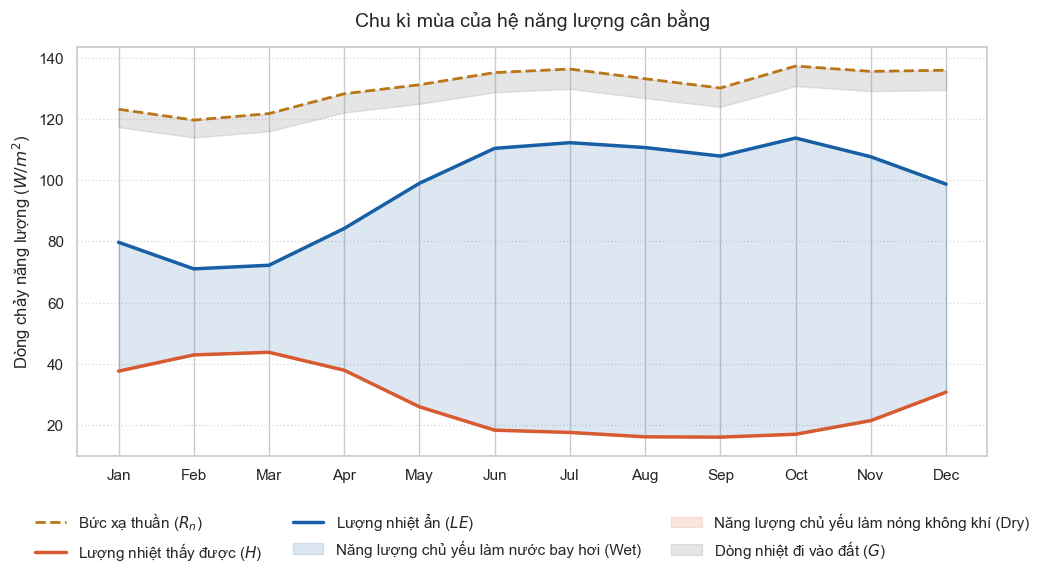

In [32]:
months   = df_clim['month']
mon_lbls = ["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]

# Extract H and LE
clim_shf = df_clim['shf']
clim_lhf = df_clim['lhf']

# Calculate Rn (Net Radiation)
clim_rad = clim_shf + clim_lhf + (0.05 * (clim_shf + clim_lhf)) 

fig, ax = plt.subplots(figsize=(11, 6))

# Plot Net Radiation (Rn) as a dashed line above H and LE
ax.plot(months, clim_rad, color="#BA7517", linewidth=2,
        linestyle="--", label="Bức xạ thuần ($R_n$)")

# Plot Sensible (H) and Latent (LE) as solid lines
ax.plot(months, clim_shf, color="#D85A30", linewidth=2.5, label="Lượng nhiệt thấy được ($H$)")
ax.plot(months, clim_lhf, color="#185FA5", linewidth=2.5, label="Lượng nhiệt ẩn ($LE$)")

# Visual Enhancements
# Fill the area between H and LE to highlight the seasonal crossover
ax.fill_between(months, clim_shf, clim_lhf, 
                where=(clim_lhf > clim_shf), interpolate=True,
                alpha=0.15, color="#185FA5", label="Năng lượng chủ yếu làm nước bay hơi (Wet)")
ax.fill_between(months, clim_shf, clim_lhf, 
                where=(clim_shf >= clim_lhf), interpolate=True,
                alpha=0.15, color="#D85A30", label="Năng lượng chủ yếu làm nóng không khí (Dry)")

# Optional: Fill the gap between Rn and (H+LE) to show Soil Heat Flux (G)
ax.fill_between(months, (clim_shf + clim_lhf), clim_rad, 
                color="gray", alpha=0.2, label="Dòng nhiệt đi vào đất ($G$)")

# Formatting
ax.set_xticks(months)
ax.set_xticklabels(mon_lbls)
ax.set_ylabel("Dòng chảy năng lượng ($W/m^2$)", fontsize=12)
ax.set_title("Chu kì mùa của hệ năng lượng cân bằng", fontsize=14, pad=15)
ax.grid(axis='y', linestyle=':', alpha=0.7)

# Move legend outside or to the best location
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

## 2. Chu kì và xu hướng dài hạn của tỉ lệ Bowen

Xét về chu kì theo mùa của tỉ lệ Bowen, khi sang mùa hè, tỉ lệ Bowen giảm đi thấp nhất, bề mặt đang trở nên ẩm hơn theo thời gian, xu hướng dài hạn của tỉ lệ Bowen cũng là giảm. Vì thế ta thấy rằng đang có biến đổi khí hậu, vì xu hướng ấm lên toàn cầu làm tăng sự bay hơi, tăng năng lượng làm bay hơi lên.

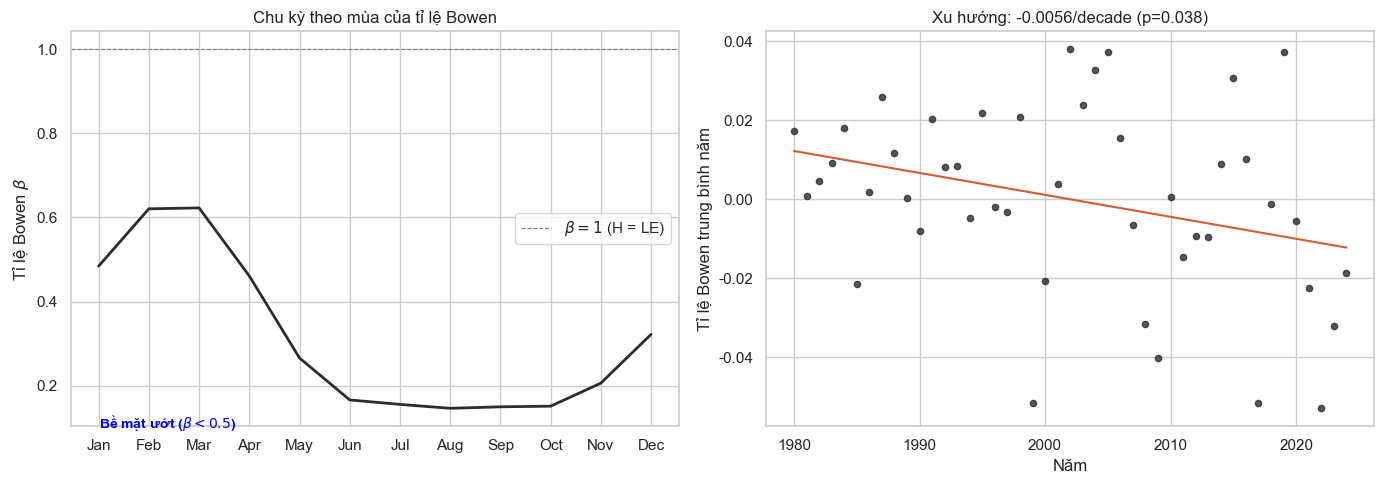

In [33]:
df_daily['time'] = pd.to_datetime(df_daily['time'])
if 'anom_br' in df_daily.columns: # Using your column name or calculating
    daily_br = df_daily.set_index('time')['anom_br'] # Use the Bowen Ratio col
else:
    daily_br = df_daily.set_index('time')['shf'] / df_daily['lhf']

# Calculate annual mean Bowen Ratio
annual_br = daily_br.resample('YE').mean()
years = annual_br.index.year.values
br_values = annual_br.values

# Linear Regression for the Trend
slope, intercept, r, p, se = stats.linregress(years, br_values)
fit_line = intercept + slope * years

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PANEL: Seasonal Climatology
months = df_clim['month']
mon_lbls = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

axes[0].plot(months, df_clim['br'], color="#2C2C2A", linewidth=2)
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label=r"$\beta = 1$ (H = LE)")
axes[0].text(1, 0.1, r"Bề mặt ướt ($\beta < 0.5$)", color='blue', fontsize=10, fontweight='bold')
axes[0].set_xticks(months)
axes[0].set_xticklabels(mon_lbls)
axes[0].set_ylabel(r"Tỉ lệ Bowen $\beta$")
axes[0].set_title("Chu kỳ theo mùa của tỉ lệ Bowen")
axes[0].legend()

# RIGHT PANEL: Long-term Trend
axes[1].scatter(years, br_values, s=20, color="#2C2C2A", alpha=0.8, zorder=3)
axes[1].plot(years, fit_line, color="#D85A30", linewidth=1.5)
axes[1].set_ylabel("Tỉ lệ Bowen trung bình năm")
axes[1].set_title(f"Xu hướng: {slope*10:+.4f}/decade (p={p:.3f})")
axes[1].set_xlabel("Năm")

plt.tight_layout()
plt.show()

## 4. Heatmap dị thường tỉ lệ Bowen

Từ heatmap này, ta thấy được biến động mạnh tập trung từ tháng 1 đến tháng 4, biến động ổn định nhất là tháng 6 đến tháng 9, khi mùa mưa xảy ra, giúp tỉ lệ Bowen thấp, dị thường ít. Còn trong những năm gần đây, ta lại thấy có dấu hiệu dị thường Bowen trong tháng 1 đến tháng 4 thấp đi, điều này có nghĩa là ẩm hơn bình thường rất cao.

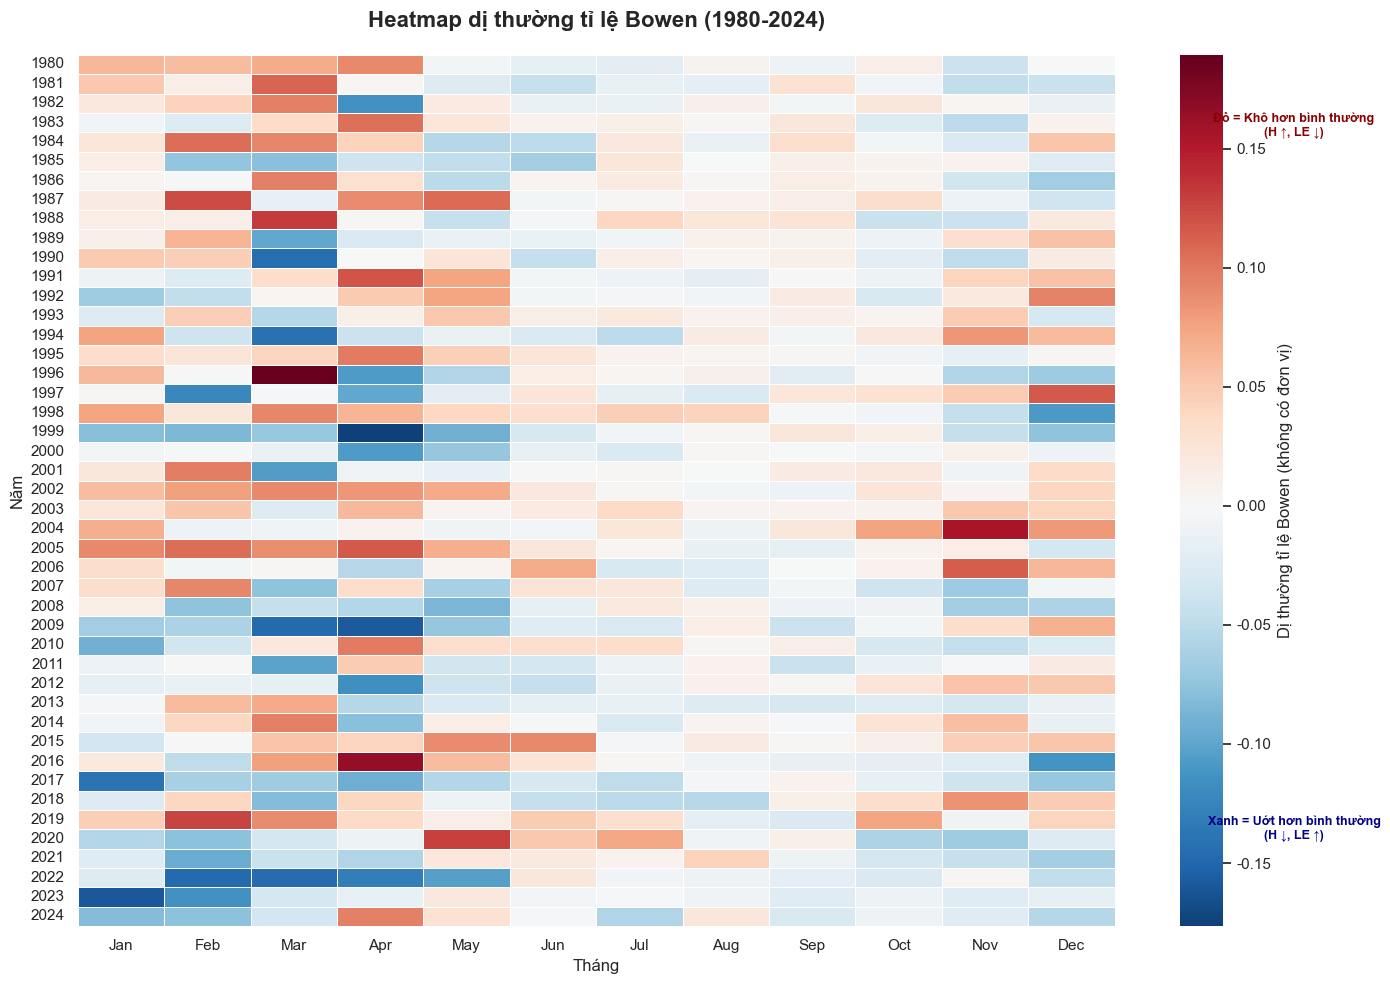

In [ ]:
# Ensure time is datetime and extract year and month
df_monthly['time'] = pd.to_datetime(df_monthly['time'])
df_monthly['year'] = df_monthly['time'].dt.year
df_monthly['month'] = df_monthly['time'].dt.month

# Calculate the Anomaly
# Merge the monthly data with the climatology data on 'month'
df_anom = df_monthly.merge(df_clim[['month', 'br']], on='month', suffixes=('', '_clim'))

# Anomaly = Actual Bowen Ratio - Climatological Mean Bowen Ratio
df_anom['br_anomaly'] = df_anom['br'] - df_anom['br_clim']

# Pivot the data for the heatmap (Rows=Year, Columns=Month)
pivot_anom = df_anom.pivot(index='year', columns='month', values='br_anomaly')

plt.figure(figsize=(14, 10))

# Month labels for the X-axis
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create heatmap
# cmap='RdBu_r' uses Red for positive (dry) and Blue for negative (wet)
# center=0 ensures the white color represents the mean
sns.heatmap(pivot_anom, 
            cmap='RdBu_r', 
            center=0, 
            annot=False, 
            linewidths=.5, 
            cbar_kws={'label': 'Dị thường tỉ lệ Bowen (không có đơn vị)'},
            xticklabels=month_labels)

plt.title('Heatmap dị thường tỉ lệ Bowen (1980-2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Năm', fontsize=12)

fig = plt.gcf()
fig.text(0.93, 0.88, 'Đỏ = Khô hơn bình thường\n(H ↑, LE ↓)',
         fontsize=9, color='darkred', fontweight='bold',
         ha='center', va='top')

fig.text(0.93, 0.15, 'Xanh = Uớt hơn bình thường\n(H ↓, LE ↑)',
         fontsize=9, color='darkblue', fontweight='bold',
         ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Xu hướng chuyển dịch theo mùa của tỉ lệ Bowen qua các thập kỉ

Phân tích được qua các thập kỉ thì xu hướng tỉ lệ Bowen không thay đổi nhiều, giữ nguyên được mức trung vị và sự khác biệt giữa các mùa:
- Mùa đông (khô): Tỉ lệ Bowen rất lớn do lượng nhiệt nhìn được (H) chiếm tỉ trọng lớn, sang những năm 2020 trở đi thì trung vị cũng giảm xuống, hộp thu hẹp đáng kể, thể hiện ra rằng có xu hướng ẩm ướt hơn, biến đổi khí hậu rõ rệt hơn.
- Mùa xuân (chuyển tiếp 1): Do là mùa chuyển tiếp nên tỉ lệ Bowen có sự biến động mạnh hơn.
- Mùa hạ (mưa): Tỉ lệ Bowen thấp nhất, chứng tỏ lượng nhiệt ẩn (LE) hoàn toàn áp đảo, thể hiện rõ tính chất bay hơi mạnh do rất ẩm ướt. 
- Mùa thu (chuyển tiếp 2): Vẫn còn ẩm vì tỉ lệ Bowen chưa cao lên, ổn định qua nhiều thập kỉ.

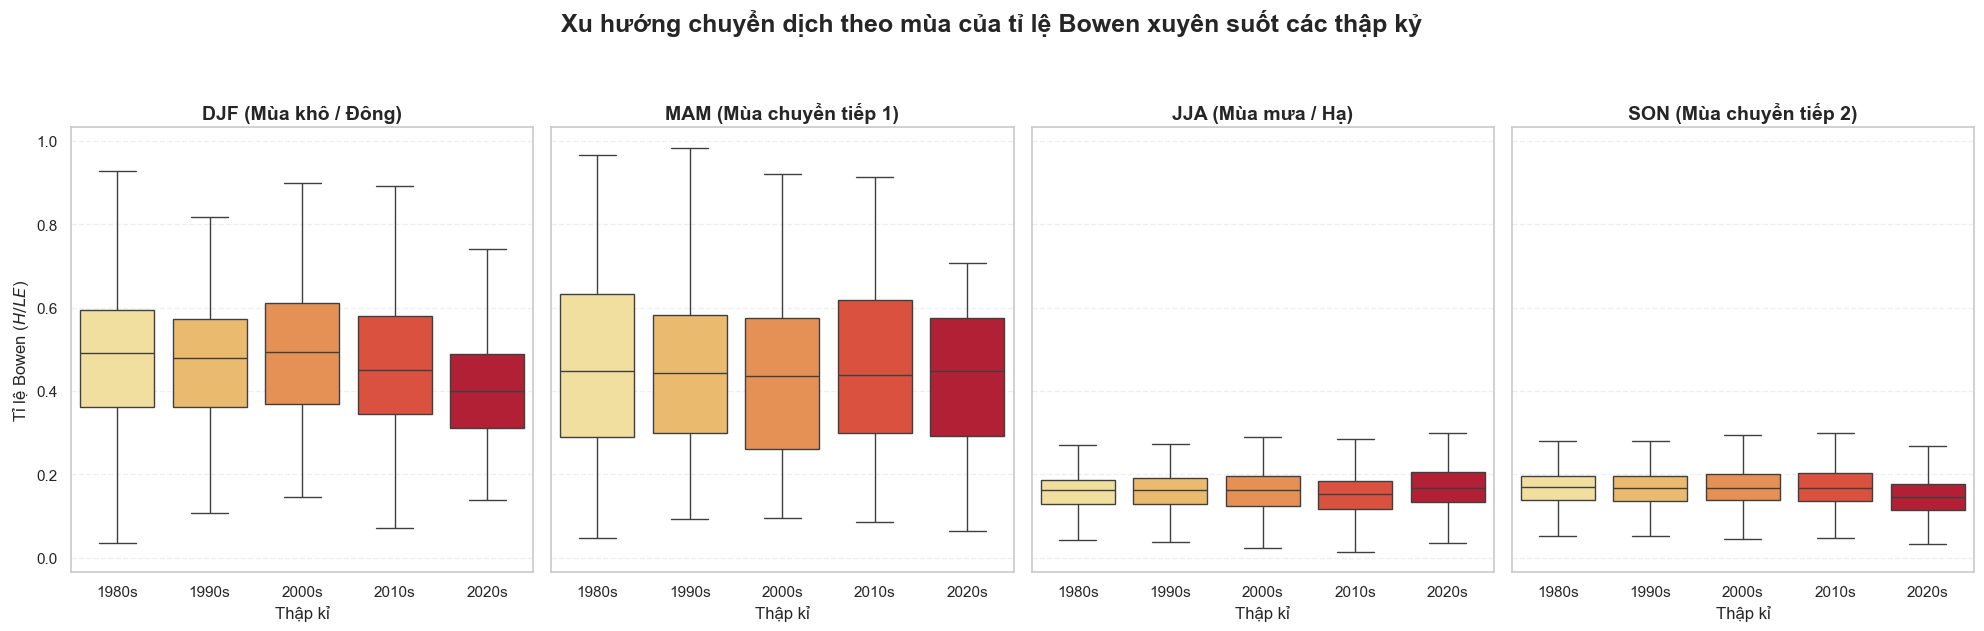

In [35]:
df_plot = df_daily.copy()
if 'time' not in df_plot.columns:
    df_plot = df_plot.reset_index()

# Calculate Bowen Ratio (H/LE)
df_plot['br'] = df_plot['shf'] / df_plot['lhf']

# Assign Decades
df_plot['year'] = df_plot['time'].dt.year
df_plot['decade'] = (df_plot['year'] // 10) * 10
df_plot['decade_label'] = df_plot['decade'].astype(str) + 's'

# Define seasons, adjust the months here based on your specific region's wet/dry timing
def get_season(month):
    if month in [12, 1, 2]: return 'DJF (Mùa khô / Đông)'
    if month in [3, 4, 5]: return 'MAM (Mùa chuyển tiếp 1)'
    if month in [6, 7, 8]: return 'JJA (Mùa mưa / Hạ)'
    if month in [9, 10, 11]: return 'SON (Mùa chuyển tiếp 2)'

df_plot['season'] = df_plot['month'].apply(get_season)

# Remove infinite or extreme values for a cleaner plot (Bowen ratio rarely exceeds 5 in most regions)
df_clean = df_plot[df_plot['br'].between(0, 5)].copy()

# We create a 1x4 grid (one plot per season)
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)

# We define the order manually so the plot follows the seasonal cycle
season_order = ['DJF (Mùa khô / Đông)', 'MAM (Mùa chuyển tiếp 1)', 'JJA (Mùa mưa / Hạ)', 'SON (Mùa chuyển tiếp 2)']

# Color palette for decades
palette = sns.color_palette("YlOrRd", n_colors=len(df_clean['decade_label'].unique()))

for i, season in enumerate(season_order):
    season_data = df_clean[df_clean['season'] == season]
    
    # Check if we have data for this season to avoid empty plot errors
    if not season_data.empty:
        sns.boxplot(ax=axes[i], 
                    x='decade_label', 
                    y='br', 
                    data=season_data, 
                    palette=palette,
                    showfliers=False,
                    hue='decade_label', # Adding hue to avoid warnings in newer seaborn
                    legend=False)
    
    axes[i].set_title(season, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Thập kỉ')
    
    if i == 0:
        axes[i].set_ylabel('Tỉ lệ Bowen ($H/LE$)', fontsize=12)
    else:
        axes[i].set_ylabel('')
    
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Xu hướng chuyển dịch theo mùa của tỉ lệ Bowen xuyên suốt các thập kỷ', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()